In [20]:
import numpy as np 
import pandas as pd

In [21]:
df = pd.read_csv('Churn_Modelling.csv')

In [22]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [24]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [26]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [27]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [28]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [29]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values



In [30]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)
x_scaled

array([[-0.32622142,  0.29351742, -1.04175968, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [-0.44003595,  0.19816383, -1.38753759, ..., -0.57873591,
         1.74273971, -1.09598752],
       [-1.53679418,  0.29351742,  1.03290776, ..., -0.57873591,
        -0.57380915, -1.09598752],
       ...,
       [ 0.60498839, -0.27860412,  0.68712986, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [ 1.25683526,  0.29351742, -0.69598177, ...,  1.72790383,
        -0.57380915,  0.91241915],
       [ 1.46377078, -1.04143285, -0.35020386, ..., -0.57873591,
        -0.57380915, -1.09598752]])

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=1)

In [33]:
# !pip install tensorflow

In [34]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [37]:
# X.shape

In [70]:
# model = Sequential()
# model.add(Dense(3,activation='sigmoid',input_dim=11))
# model.add(Dense(1,activation='sigmoid'))

In [78]:
model = Sequential()

model.add(Dense(5,activation='relu',input_dim=11))
model.add(Dense(5,activation='relu'))
model.add(Dense(5,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [79]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 5)                   │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 126 (504.00 B)

 Trainable params: 126 (504.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [81]:
# history = model.fit(X_train,y_train,epochs=10)

In [82]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6891 - loss: 0.6417 - val_accuracy: 0.7975 - val_loss: 0.5195
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7923 - loss: 0.5102 - val_accuracy: 0.7975 - val_loss: 0.4752
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7893 - loss: 0.4834 - val_accuracy: 0.7975 - val_loss: 0.4524
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8068 - loss: 0.4410 - val_accuracy: 0.7975 - val_loss: 0.4389
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7999 - loss: 0.4248 - val_accuracy: 0.7975 - val_loss: 0.4306
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7846 - loss: 0.4406 - val_accuracy: 0.7975 - val_loss: 0.4263
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8015 - loss: 0.4253 - val_accuracy: 0.7975 - val_loss: 0.4224
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7991 - loss: 0.4092 - val_accu

In [46]:
import matplotlib.pyplot as plt

In [ ]:
# history.history

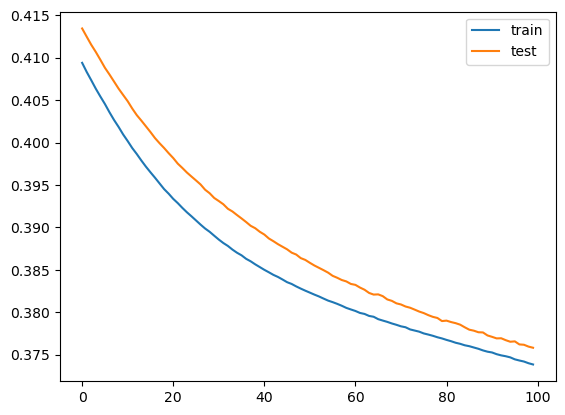

In [51]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend();

In [56]:
model.layers[1].get_weights()

[array([[-2.2670858],
        [-2.5010056],
        [-2.238573 ]], dtype=float32),
 array([2.5610626], dtype=float32)]

In [60]:
y_train

array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

In [57]:
y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [64]:
y_pred_train= np.where(y_pred_train>0.5,1,0)

In [66]:
y_pred_test= np.where(y_pred_test>0.5,1,0)

In [67]:
from sklearn.metrics import accuracy_score


In [68]:
accuracy_score(y_train,y_pred_train)

0.848125

In [69]:
accuracy_score(y_test,y_pred_test)

0.85

In [26]:
y_test

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [27]:
y_pred_test

array([[0.13140337],
       [0.16057934],
       [0.14523917],
       ...,
       [0.08752784],
       [0.14932457],
       [0.3595034 ]], dtype=float32)

In [59]:
accuracy_score(y_test,y_pred_test)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [140]:
# history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

In [141]:
# model.layers[0].get_weights()

[array([[ 0.11454844, -0.03460454,  0.43789324],
        [-0.47376338, -0.66763276, -0.05764589],
        [ 0.21912718, -0.24998693, -0.41374692],
        [ 0.4855461 ,  0.37458408,  0.47309184],
        [ 0.07190663, -0.5520289 ,  0.56069386],
        [-0.46914336,  0.5118418 , -0.37263662],
        [ 0.3222236 , -0.21578081, -0.36982882],
        [ 0.47085834, -0.01828504, -0.39980894],
        [ 0.2745449 , -0.06624573,  0.33975628],
        [-0.28744268,  0.07606358, -0.37734804],
        [ 0.1902883 ,  0.15586163, -0.1637197 ]], dtype=float32),
 array([ 0.        , -0.05508377,  0.01602277], dtype=float32)]

In [142]:
# y_pred = model.predict(X_test)
# y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.250147  ],
       [0.250147  ],
       [0.20912911],
       ...,
       [0.20912911],
       [0.20912911],
       [0.250147  ]], dtype=float32)

In [143]:
np.where(y_pred>0.5,1,0)

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [39]:
y_pred_test = y_pred_test.argmax(axis=-1)
y_pred_test

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_test)

0.7925

In [44]:
y_pred_train = y_pred_train.argmax(axis=-1)
y_pred_train

0

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred_train)

InvalidParameterError: The 'y_pred' parameter of accuracy_score must be an array-like or a sparse matrix. Got 0 instead.

KeyError: 'val_loss'

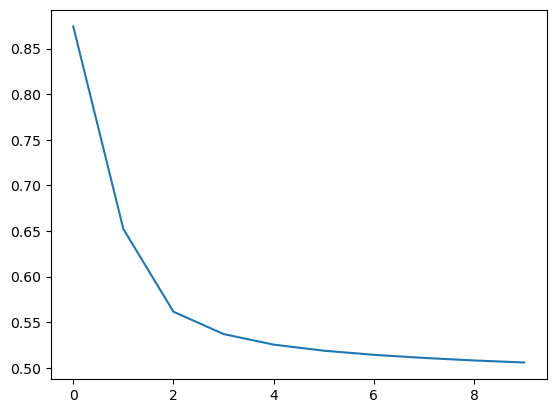

In [146]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])